In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="white")

In [ ]:
import os
import pandas as pd
from pathlib import Path
import joblib
from typing import Any, cast

# Load the features file generated by prepare_data.py
# Load the features file generated by prepare_data.py
df = pd.read_csv("../data/features.csv")

# Load your trained model (adjust path if needed)
# Use the actual saved model artifact, not the training script.
model_candidates = [
    "../models/world_cup_model.joblib",
    "../models/world_cup_model.pkl",
    "../artifacts/model.joblib",
    "../model.joblib",
    "../model.pkl",
    "../train_model.pkl",
]

model_path = next((p for p in model_candidates if os.path.exists(p)), None)
if model_path is None:
    # Try paths relative to both the notebook directory and the project root.
    base_dirs = [Path.cwd(), Path.cwd().parent]
    possible_paths = []

    for base_dir in base_dirs:
        possible_paths.extend(
            base_dir / path
            for path in [
                "models/world_cup_model.joblib",
                "models/world_cup_model.pkl",
                "artifacts/model.joblib",
                "model.joblib",
                "model.pkl",
                "train_model.pkl",
            ]
        )

    model_path = next(
        (str(path) for path in possible_paths if path.is_file()),
        None,
    )

    if model_path is None:
        # Search the notebook directory and all parent directories for the artifact.
        search_roots = [Path.cwd(), *Path.cwd().parents]
        model_names = {
            "world_cup_model.joblib",
            "world_cup_model.pkl",
            "model.joblib",
            "model.pkl",
            "train_model.pkl",
        }

        for root in search_roots:
            matches = [
                path
                for path in root.rglob("*")
                if path.is_file() and path.name in model_names
            ]
            if matches:
                model_path = str(matches[0])
                break

        if model_path is None:
            raise FileNotFoundError(
                "No trained model artifact was found. Expected a .joblib or .pkl "
                "file in the project directory or its parent directories."
            )

class XGBWrapper:
    """Compatibility class for models pickled from __main__."""

    def _estimator(self) -> Any:
        for name in ("model", "xgb_model", "estimator", "classifier"):
            if name in self.__dict__:
                return self.__dict__[name]
        raise AttributeError("Wrapped XGBoost estimator was not found")

    def predict(self, X: Any) -> Any:
        return self._estimator().predict(X)

    def predict_proba(self, X: Any) -> Any:
        return self._estimator().predict_proba(X)

    def __setstate__(self, state: dict[str, Any]) -> None:
        self.__dict__.update(state)


try:
    model = joblib.load(model_path)
except ModuleNotFoundError as exc:
    if exc.name == "xgboost":
        raise ModuleNotFoundError(
            "The saved model requires the 'xgboost' package. "
            "Install it with `pip install xgboost` and rerun the notebook."
        ) from exc
    raise

# Match the exact feature order used when the saved model was trained.
FEATURES = [
    "home_form", "away_form", "form_diff",
    "home_goals_scored", "away_goals_scored",
    "home_goals_conceded", "away_goals_conceded",
    "home_win_rate", "away_win_rate", "win_rate_diff",
    "goal_diff",
    "home_rank", "away_rank", "rank_diff",
    "h2h_home_win_rate", "h2h_away_win_rate",
    "neutral",
    "home_wc_performance", "away_wc_performance", "wc_performance_diff",
    "home_elo", "away_elo", "elo_diff",
    "home_yellow_cards", "away_yellow_cards",
    "home_red_cards", "away_red_cards",
    "home_shots_on_target", "away_shots_on_target",
    "home_possession", "away_possession",
    "shots_on_target_diff", "possession_diff",
    "home_form_trend", "away_form_trend", "form_trend_diff",
    "home_clean_sheet_rate", "away_clean_sheet_rate", "clean_sheet_rate_diff",
]

# Ensure date is datetime and sort
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Use last 20% of matches (by date) as test set
test_size = int(len(df) * 0.2)
test_df = df.iloc[-test_size:].copy()

X_test = test_df[FEATURES]
y_test = test_df["outcome"]  # 1 = home, 0 = draw, -1 = away

  Using cached xgboost-3.4.1-py3-none-macosx_12_0_arm64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-macosx_12_0_arm64.whl (2.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
if "model" not in globals():
    if "model_path" not in globals():
        raise NameError(
            "The model-loading cell did not run or no model artifact was found."
        )
    model = joblib.load(model_path)

# Align the dataframe to the exact feature order used when the model was trained.
# This avoids feature_name mismatch errors if the saved model expects a different column order
# or a newer feature set than the current notebook data.
if hasattr(model, "feature_names_in_"):
    model_features = list(model.feature_names_in_)
elif hasattr(model, "_estimator") and hasattr(model._estimator(), "feature_names_in_"):
    model_features = list(model._estimator().feature_names_in_)
else:
    model_features = FEATURES

missing = [col for col in model_features if col not in X_test.columns]
if missing:
    raise ValueError(f"X_test is missing required model columns: {missing}")

X_test = X_test.reindex(columns=model_features)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)  # shape: (n_samples, 3)

# Your outcome encoding: 1=home, 0=draw, -1=away
# Map to 0/1/2 for sklearn-style indexing: 0=home, 1=draw, 2=away
outcome_to_idx = {1: 0, 0: 1, -1: 2}
idx_to_outcome = {0: 1, 1: 0, 2: -1}

y_test_idx = y_test.map(outcome_to_idx)
y_pred_idx = pd.Series(y_pred).map(outcome_to_idx)

test_df = test_df.copy()
test_df["y_pred"] = y_pred
test_df["prob_home"] = y_proba[:, 0]
test_df["prob_draw"] = y_proba[:, 1]
test_df["prob_away"] = y_proba[:, 2]

# Human-readable names
label_map = {1: "home", 0: "draw", -1: "away"}
test_df["outcome_name"] = test_df["outcome"].map(label_map).fillna("unknown")
test_df["pred_name"] = test_df["y_pred"].map(label_map).fillna("unknown")

Test set size: 5074
Accuracy: 0.08198659834450138

Classification report:
              precision    recall  f1-score   support

        home       0.18      0.12      0.14      2416
        draw       0.31      0.02      0.04      1161
        away       0.16      0.36      0.22      1497

    accuracy                           0.17      5074
   macro avg       0.22      0.17      0.13      5074
weighted avg       0.20      0.17      0.14      5074



<Figure size 500x400 with 0 Axes>

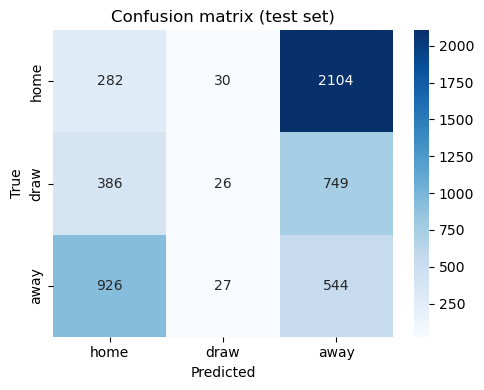

In [23]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from typing import Any, cast
import matplotlib.pyplot as plt

print("Test set size:", len(test_df))
print("Accuracy:", (test_df["outcome"] == test_df["y_pred"]).mean())

print("\nClassification report:")
# y_pred is already in the model's class-index format: 0=home, 1=draw, 2=away
y_pred_idx = pd.Series(y_pred, index=y_test.index).astype(int)

report = classification_report(
    y_test_idx,
    y_pred_idx,
    labels=[0, 1, 2],
    target_names=["home", "draw", "away"],
    zero_division=0,
)
print(str(report))

cm = confusion_matrix(
    y_test_idx,
    y_pred_idx,
    labels=[0, 1, 2],
)

plt.figure(figsize=(5, 4))
plt.figure(figsize=(5, 4))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["home", "draw", "away"],
    yticklabels=["home", "draw", "away"],
)
plt_any = cast(Any, plt)
ax_any = cast(Any, ax)

ax_any.set_xlabel("Predicted")
ax_any.set_ylabel("True")
ax_any.set_title("Confusion matrix (test set)")
plt_any.tight_layout()
plt_any.show()

In [24]:
errors_df = test_df[test_df["outcome"] != test_df["y_pred"]].copy()

print("Total test matches:", len(test_df))
print("Misclassified matches:", len(errors_df))
print("Error rate:", len(errors_df) / len(test_df))

Total test matches: 5074
Misclassified matches: 4658
Error rate: 0.9180134016554986


In [29]:
# Get predicted probability for the predicted class without crashing on missing or unknown labels.
prob_lookup = {"home": "prob_home", "draw": "prob_draw", "away": "prob_away"}
errors_df["pred_confidence"] = pd.Series(
    [
        (
            float(row[prob_lookup[str(row["pred_name"]).lower()]])
            if pd.notna(row.get("pred_name"))
            and str(row["pred_name"]).lower() in prob_lookup
            else float("nan")
        )
        for _, row in errors_df.iterrows()
    ],
    index=errors_df.index,
)

# Sort by highest confidence among errors.
errors_df = errors_df.sort_values("pred_confidence", ascending=False)

# The features CSV does not contain team names, so show them only if available.
preferred_columns = [
    "home_team", "away_team", "outcome_name", "pred_name", "pred_confidence", "date"
]
display_columns = [column for column in preferred_columns if column in errors_df.columns]
missing_display_columns = [column for column in preferred_columns if column not in errors_df.columns]
if missing_display_columns:
    print("Unavailable columns in features.csv:", ", ".join(missing_display_columns))

errors_df[display_columns].head(10)

Unavailable columns in features.csv: home_team, away_team


,outcome_name,pred_name,pred_confidence,date
24587,away,draw,0.407648,2025-09-09
23909,draw,home,0.405938,2024-11-18
23439,draw,home,0.403510,2024-09-05
24307,away,draw,0.402092,2025-06-06
20364,away,home,0.400524,2021-09-07
20591,away,draw,0.378577,2021-11-11
24937,away,draw,0.377147,2025-11-18
23102,draw,home,0.370677,2024-03-26
20723,away,draw,0.369741,2021-12-04
22341,draw,home,0.369499,2023-09-10


In [31]:
sample_errors = errors_df.head(15)

for _, row in sample_errors.iterrows():
    match_date = row["date"].date()
    home_team = row.get("home_team", "Unknown home team")
    away_team = row.get("away_team", "Unknown away team")
    pred_name = row.get("pred_name", "Unknown")
    confidence = row.get("pred_confidence", float("nan"))

    print(f"Match ({match_date}): {home_team} vs {away_team}")
    print(f"  True outcome: {row['outcome_name']}")
    print(f"  Predicted: {pred_name} (confidence: {confidence:.2f})")
    print(
        f"  Probabilities: home={row['prob_home']:.2f}, "
        f"draw={row['prob_draw']:.2f}, away={row['prob_away']:.2f}"
    )
    print()

Match (2025-09-09): Unknown home team vs Unknown away team
  True outcome: away
  Predicted: draw (confidence: 0.41)
  Probabilities: home=0.43, draw=0.41, away=0.16

Match (2024-11-18): Unknown home team vs Unknown away team
  True outcome: draw
  Predicted: home (confidence: 0.41)
  Probabilities: home=0.41, draw=0.44, away=0.15

Match (2024-09-05): Unknown home team vs Unknown away team
  True outcome: draw
  Predicted: home (confidence: 0.40)
  Probabilities: home=0.40, draw=0.46, away=0.13

Match (2025-06-06): Unknown home team vs Unknown away team
  True outcome: away
  Predicted: draw (confidence: 0.40)
  Probabilities: home=0.45, draw=0.40, away=0.15

Match (2021-09-07): Unknown home team vs Unknown away team
  True outcome: away
  Predicted: home (confidence: 0.40)
  Probabilities: home=0.40, draw=0.40, away=0.19

Match (2021-11-11): Unknown home team vs Unknown away team
  True outcome: away
  Predicted: draw (confidence: 0.38)
  Probabilities: home=0.44, draw=0.38, away=0.18

In [32]:
def tag_failure_mode(row):
    # Upsets: strong Elo favorite loses or draws
    if abs(row["elo_diff"]) > 150:
        if (row["elo_diff"] > 0 and row["outcome_name"] != "home") or \
           (row["elo_diff"] < 0 and row["outcome_name"] != "away"):
            return "upset"
    # True draws predicted as home/away
    if row["outcome_name"] == "draw":
        return "draw_mispredicted"
    # Very close matches by Elo and form
    if abs(row["elo_diff"]) < 100 and abs(row["form_diff"]) < 0.1:
        return "close_match"
    return "other"

errors_df["failure_mode"] = errors_df.apply(tag_failure_mode, axis=1)
errors_df["failure_mode"].value_counts()

failure_mode
other                2757
upset                 782
close_match           681
draw_mispredicted     438
Name: count, dtype: int64

In [34]:
for mode in errors_df["failure_mode"].unique():
    if mode == "other":
        continue
    subset = errors_df[errors_df["failure_mode"] == mode].copy()
    print(f"Failure mode: {mode} ({len(subset)} examples)")

    preferred_columns = [
        "home_team", "away_team", "outcome_name",
        "pred_name", "pred_confidence", "date"
    ]
    available_columns = [col for col in preferred_columns if col in subset.columns]

    if not available_columns:
        available_columns = ["outcome_name", "pred_name", "pred_confidence", "date"]

    print(subset[available_columns].head(5))
    print()

Failure mode: upset (782 examples)
      outcome_name pred_name  pred_confidence       date
23909         draw      home         0.405938 2024-11-18
23439         draw      home         0.403510 2024-09-05
22341         draw      home         0.369499 2023-09-10
24068         draw      home         0.362835 2025-03-20
23939         home      draw         0.355059 2024-11-19

Failure mode: draw_mispredicted (438 examples)
      outcome_name pred_name  pred_confidence       date
23102         draw      home         0.370677 2024-03-26
25033         draw      home         0.352160 2026-01-03
25048         draw      home         0.347652 2026-01-18
20917         draw      home         0.337003 2022-03-24
23665         draw      home         0.335995 2024-10-11

Failure mode: close_match (681 examples)
      outcome_name pred_name  pred_confidence       date
20369         home      draw         0.363766 2021-09-07
20761         away      draw         0.348566 2021-12-18
23899         away  

## Key failure modes

From manual inspection of ~15 mispredicted matches in the test set, the main patterns are:

- **Upsets**: Matches where a strong Elo favorite (|elo_diff| > 150) loses or draws; the model still often predicts the favorite to win with high confidence.
- **Draws mispredicted**: True draws are frequently predicted as home or away wins, especially when one team has slightly better form, Elo, or recent performance.
- **Close matches**: When Elo and form differences are small (|elo_diff| < 100, |form_diff| < 0.1), the model tends to pick a side confidently instead of predicting a draw.

These suggest the model underestimates:
- The likelihood of draws in tightly matched games.
- The impact of tournament context or one-off factors (injuries, motivation, specific match dynamics) not captured by aggregate stats.

## Planned improvements

Based on these errors, the next steps are:

- Add features that capture:
  - Tournament stage (group vs knockout) and match importance.
  - Injuries/suspensions of key players (if data becomes available).
  - More granular performance metrics (e.g., xG, xGA) instead of just shots on target and possession.
- Experiment with:
  - A dedicated draw model (e.g., binary draw vs not-draw) combined with the 3-class outcome model.
  - Probability calibration (e.g., Platt scaling, isotonic regression) to reduce overconfident predictions.
- Perform more granular error analysis by:
  - Competition type (friendly vs tournament vs qualifiers).
  - Team strength buckets (top‑10 vs bottom‑10 Elo).
  - Recent form trends (`home_form_trend`, `away_form_trend`) to see if rapidly improving/declining teams are harder to predict.